# Model 3 - Batch arithmetics (detailed diagram)

## Load libraries

In [1]:
import matplotlib.pyplot as plt

import libs.tools as tools
import libs.QueueApprox as QueueApprox

plt.style.use('seaborn-v0_8')

## Load and process data

In [2]:
# Number of operators needed in bS=1 case
c_needed = 16

data_fixed = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "fixed" and rec["b_min"] == c_needed and isinstance(rec["bI"], int))
tools.load_statistics(data_fixed)
data_compare = tools.prepare_statistics(-1, lambda rec: rec["mode"] == "compare")
tools.load_statistics(data_compare)

In [3]:
def find(data: list, S: str, rho: float, CVS: float, bI: int, bS: int) -> dict:
    for rec in data:
        if rec["S"] == S and rec["model_rho"] == rho and rec["model_CV[S]"] == CVS and rec["bI"] == bI and rec["b_max"] == bS:
            return rec
    raise Exception("No matching record found")


def normalize(value: float, data: list[float]):
    for i in range(len(data)):
        data[i] = data[i] / value


def sub_plot(S: str, CVS: float, rho: float, ax):
    fixed_x = list(range(1, 5))
    fixed_y = [find(data_fixed, S, rho, CVS, bI, 16)["E[W]"] for bI in fixed_x]
    compare_x = [2, 4]
    compare_y = [find(data_compare, S, rho, CVS, 1, int(16 / bI))["E[W]"] for bI in compare_x]

    ac_fixed_y = [QueueApprox.EW_approx(1 / 100 / bI, 1 / (100 * rho * 16), 1, CVS, 1, bI, 16, True) for bI in fixed_x]
    ac_compare_y = [QueueApprox.EW_approx(1 / 100 / bI, 1 / (100 * rho * 16), 1, CVS, 1, 1, int(16 / bI), True) for bI in compare_x]

    norm = fixed_y[0]
    normalize(norm, fixed_y)
    normalize(norm, compare_y)
    normalize(norm, ac_fixed_y)
    normalize(norm, ac_compare_y)

    ax.plot(fixed_x, fixed_y, marker="o", label="$b_I=n$, $b_S=16$ (simulation)")
    ax.scatter(compare_x, compare_y, marker="X", s=100, color="red", label="$b_I=1$, $b_S=16/n$ (simulation)")

    ax.plot(fixed_x, ac_fixed_y, ":", marker="o", label="$b_I=n$, $b_S=16$ (approx)")
    ax.scatter(compare_x, ac_compare_y, marker="X", s=50, color="orange", label="$b_I=1$, $b_S=16/n$ (approx)")

## Plot results

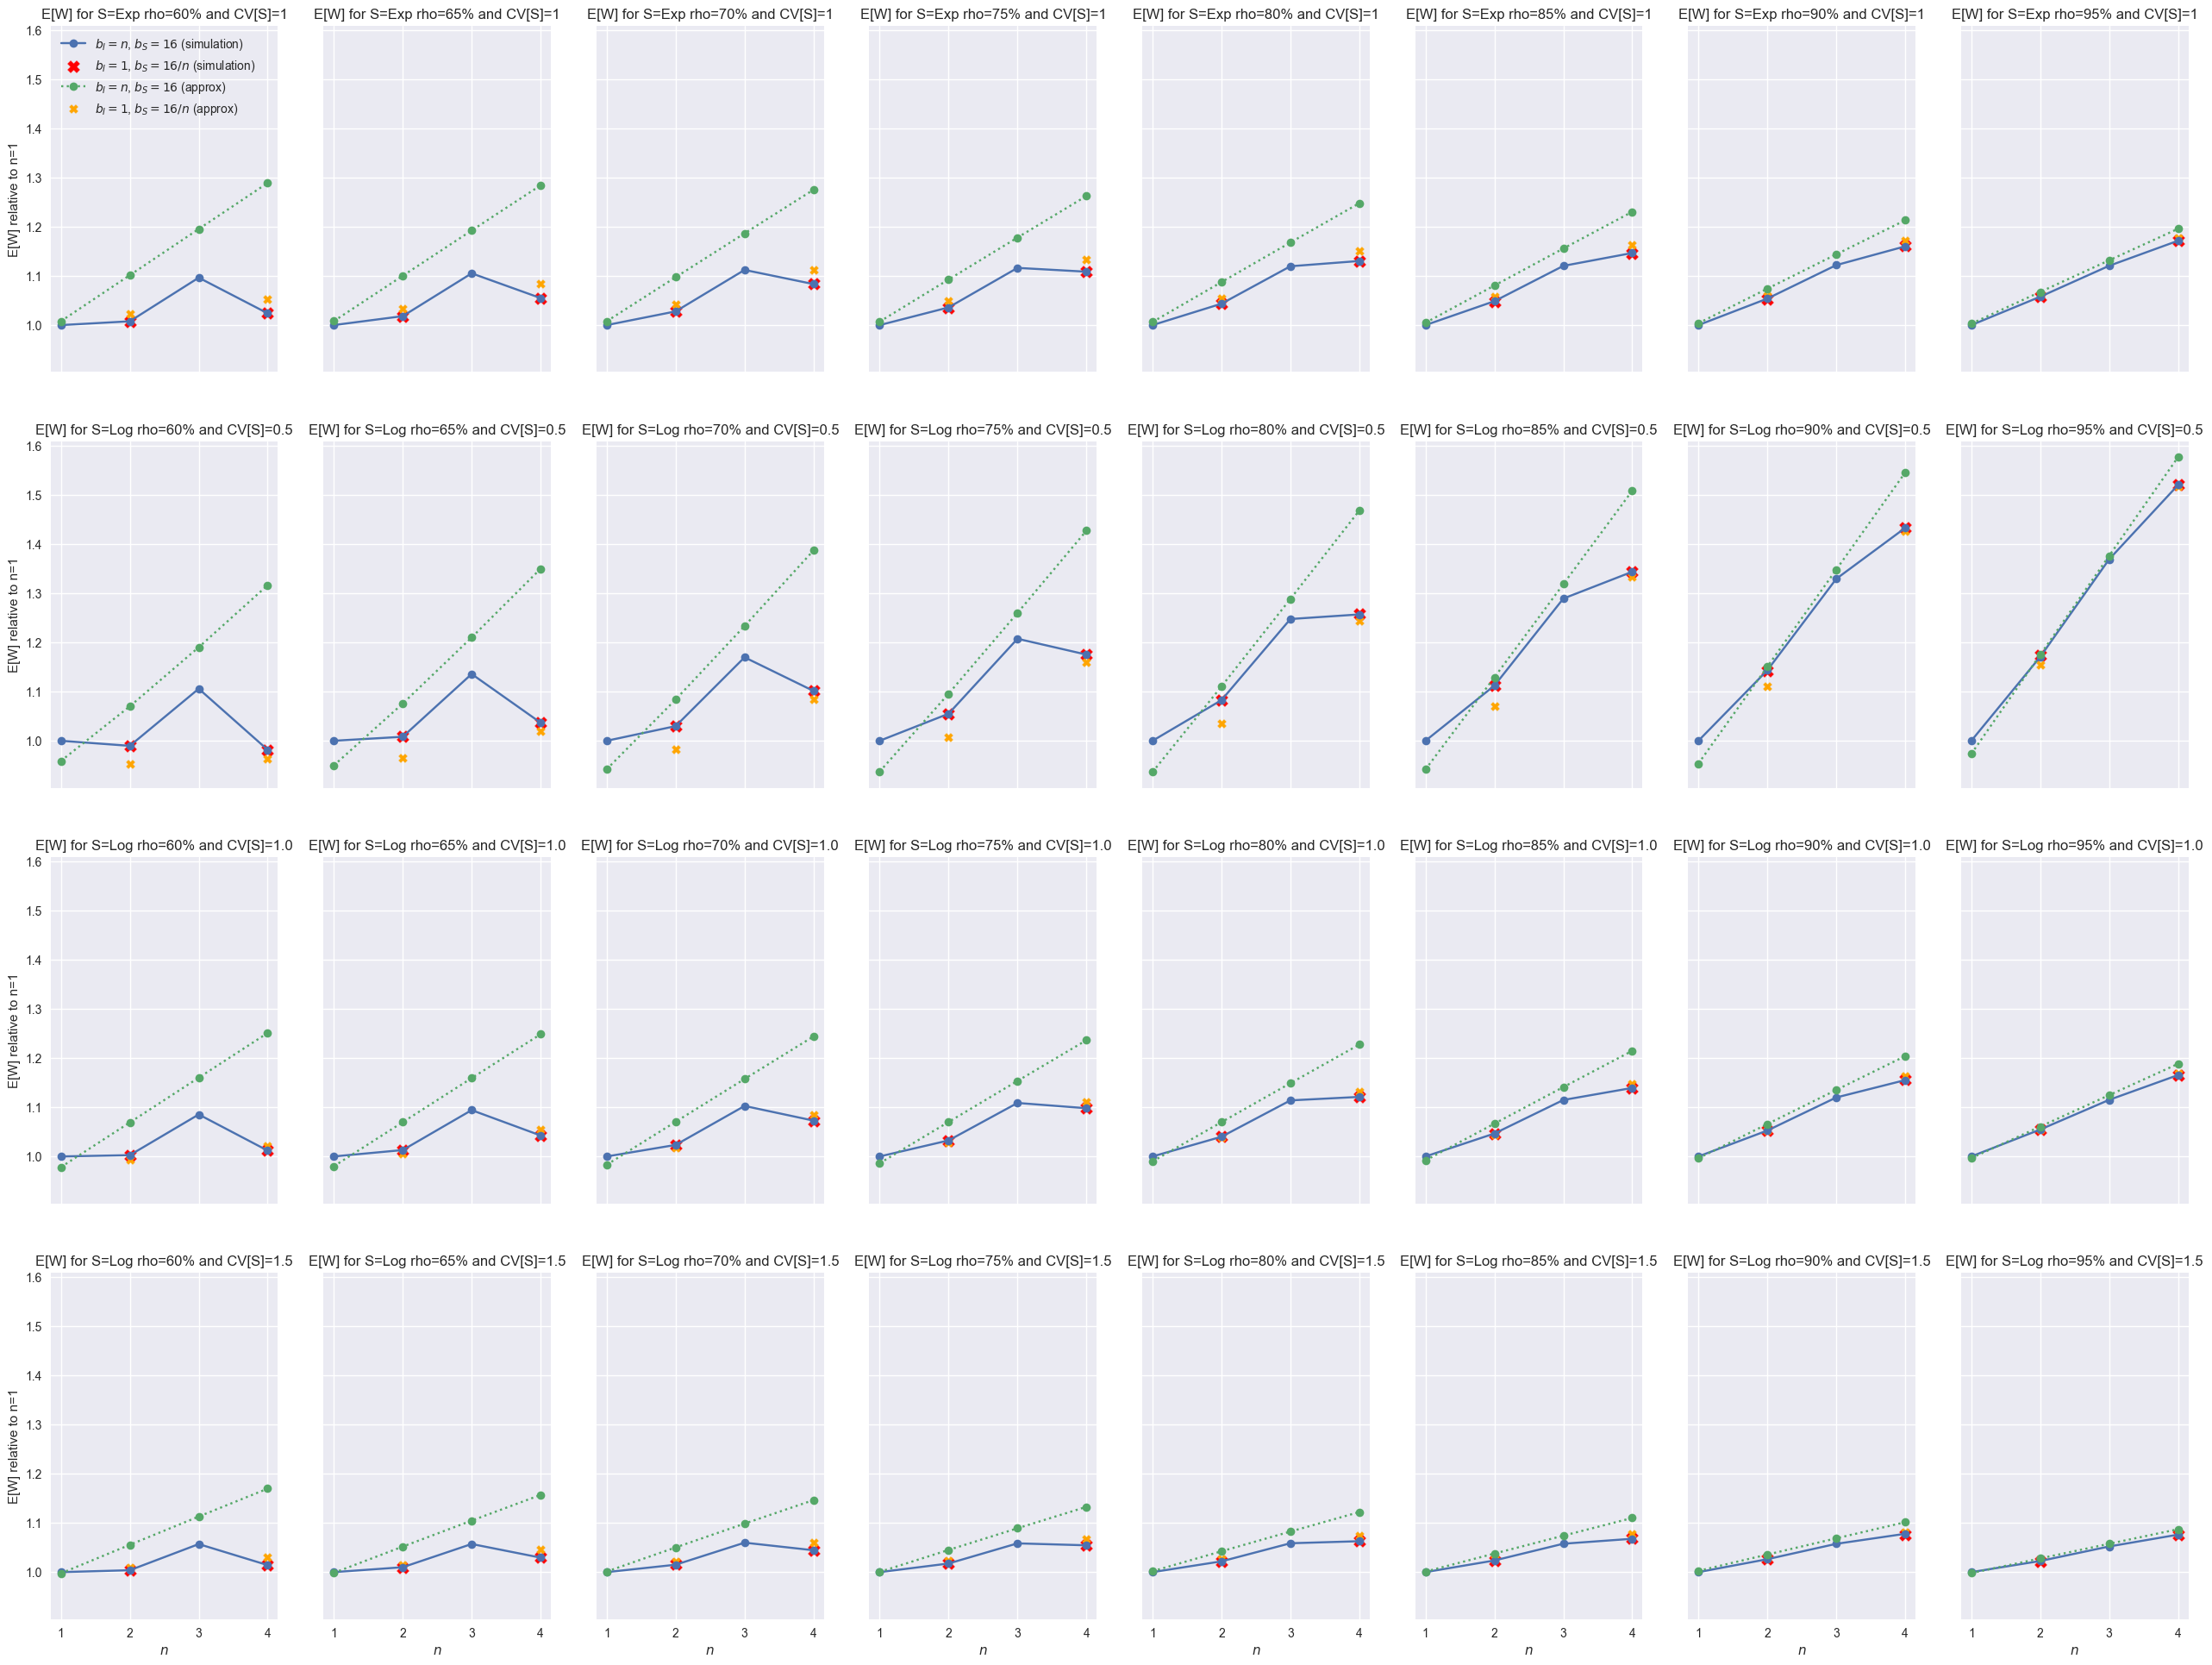

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.60 + j * 0.05

        ax1 = ax[i][j]
        sub_plot(S, CVS, rho, ax1)

        ax1.set_xticks(list(range(1, 5)))
        if j == 0:
            ax1.set_ylabel("E[W] relative to n=1")

        if i == 3:
            ax1.set_xlabel("$n$")

        ax1.set_title(f"E[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

        if i==0 and j==0:
            ax1.legend(loc=2)

# fig.savefig("images/Model03-EWrel-details.png", format="png", bbox_inches='tight', pad_inches=0)

In [5]:
S = "Exp"
CVS = 1
rho = 0.6

fixed_x = list(range(1, 5))
fixed_y = [find(data_fixed, S, rho, CVS, bI, 16)["E[W]"] for bI in fixed_x]

compare_x = [2, 4]
compare_y = [find(data_compare, S, rho, CVS, 1, int(16 / bI))["E[W]"] for bI in compare_x]

ac_fixed_y = [QueueApprox.EW_approx(1 / 100 / bI, 1 / (100 * rho * 16), 1, CVS, 1, bI, 16, True) for bI in fixed_x]

ac_compare_y = [QueueApprox.EW_approx(1 / 100 / bI, 1 / (100 * rho * 16), 1, CVS, 1, 1, int(16 / bI), True) for bI in compare_x]

print(fixed_y)
print(compare_y)
print(ac_fixed_y)
print(ac_compare_y)

[1269.5863187563002, 1279.369209370802, 1392.0930372611285, 1300.0129629994333]
[1279.2795201964063, 1300.0114080896335]
[1279.6565486121626, 1398.5829499870497, 1517.8245207542095, 1636.8576777701833]
[1298.5829499870497, 1336.8576777701833]
